# Imports

In [26]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.table import Table
from scipy.optimize import curve_fit
from statistics import mean
from sklearn.metrics import r2_score

# Set Paths

In [27]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

# Define Functions

In [28]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

def line(x_data,m,c): 
    return m*x_data + c 

def difference_list_comp(list1, list2):
    
    return [x for x in list2 if x not in list1]

def split_into_n_bins(lst, n_bins):
    sorted_lst = sorted(lst)  # optional, if bins should be ordered
    k, m = divmod(len(sorted_lst), n_bins)
    bins = [sorted_lst[i * k + min(i, m):(i + 1) * k + min(i + 1, m)] for i in range(n_bins)]
    return bins

def make_bin_bounds(list, n_bins):
    binned_redshifts = split_into_n_bins(list, n_bins)

    bin_bounds = []
    for i in range(len(binned_redshifts)):
        bound = binned_redshifts[i][0]
        bin_bounds.append(bound)
        
    bin_bounds.append(binned_redshifts[len(binned_redshifts) - 1][len(binned_redshifts[(len(binned_redshifts) - 1)]) -1])

    return bin_bounds

# Catalogs

In [29]:
LAT_IC_peaks = Table.read(catalog_dir + 'LAT_peaks_data.fits')
#LAT_IC_peaks.pprint_all()

SMBH_Catalog = Table.read(catalog_dir + 'Black_Hole_Mass_Catalog.fits')

Fermi_LAC_DR3 = Table.read(catalog_dir + 'Fermi_LAC_DR3.fits')

MeV_Blazar_Catalog = Table.read(catalog_dir + 'MeV_Blazar_Catalog_v2.fits')

Matched_Blazar_Fit_All = Table.read(catalog_dir + 'MeV_Blazar_Fits_All_results.fits')

Fermi_LAT_DR4 = Table.read(catalog_dir + "4FGLDR4.fit", hdu=1) 

LAT_IC_data = Table.read(catalog_dir + 'LAT_peaks_data.fits')

Masked_LAT_data = Table.read(catalog_dir + 'Masked_LAT_results.fits')

# Prep BH Catalog

In [30]:
LAC_DR3_Assoc_Name = []

SMBH_cat_names = SMBH_Catalog['Fermi_Name'].tolist()
for i in SMBH_cat_names:
    mask = (Fermi_LAC_DR3['Source_Name'] == i)
    assoc_name = Fermi_LAC_DR3[mask]['ASSOC1'].tolist()

    if assoc_name == []:
        assoc_name = ['None']

    LAC_DR3_Assoc_Name.append(assoc_name[0])

SMBH_cat_types = []

SMBH_cat_class = SMBH_Catalog['Class'].tolist()
for i in SMBH_cat_class:
    if i == 'F':
        type = 'FSRQ'
        SMBH_cat_types.append(type)
    if i == 'B':
        type = 'BLL'
        SMBH_cat_types.append(type)
    if i == 'U':
        type = 'BCU'
        SMBH_cat_types.append(type)

SMBH_cat_redshift = [str(x) for x in SMBH_Catalog['Redshift'].tolist()]
SMBH_cat_Gamma = SMBH_Catalog['Gamma'].tolist()
SMBH_cat_BH_mass = SMBH_Catalog['logMBH'].tolist()
SMBH_cat_BH_mass_err = SMBH_Catalog['e_logMBH'].tolist()

Black_Hole_Catalog = Table([SMBH_cat_names, LAC_DR3_Assoc_Name, SMBH_cat_types, SMBH_cat_redshift,SMBH_cat_Gamma,SMBH_cat_BH_mass,SMBH_cat_BH_mass_err], names = ['Source_Name', 'ASSOC_Name', 'Class','Redshift','Photon_Index','BH_Mass','BH_Mass_err'])
Black_Hole_Catalog.write(catalog_dir + 'LAT_DR2_BHs.fits', overwrite=True)

In [31]:
print(len(difference_list_comp(Masked_LAT_data['Name'].tolist(),SMBH_cat_names)))
print(len(SMBH_cat_names))

36
667


# Paper Sanity Checks

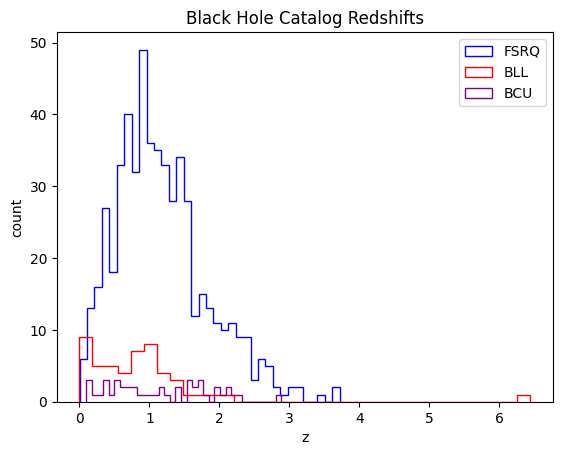

In [32]:
Black_Hole_Catalog_FSRQ, Black_Hole_Catalog_BLL, Black_Hole_Catalog_BCU = mask_catalog_by_class(Black_Hole_Catalog, 'Class')
Black_Hole_Catalog_All = [Black_Hole_Catalog_FSRQ, Black_Hole_Catalog_BLL, Black_Hole_Catalog_BCU]

labels = ['FSRQ', 'BLL', 'BCU']
colors = ['blue', 'red', 'purple']

for i in range(len(Black_Hole_Catalog_All)):
    redshift = Black_Hole_Catalog_All[i]['Redshift'].tolist()
    redshift = [float(x) for x in redshift if x != 'None']

    num_bins = 35
    
    plt.hist(redshift, num_bins, label =labels[i], color = colors[i], histtype='step')
    plt.xlabel('z')
    plt.ylabel('count')
    plt.title('Black Hole Catalog Redshifts')
    plt.legend(loc = 'upper right')

plt.savefig(outdir + 'BH_Catalog_z.png') 

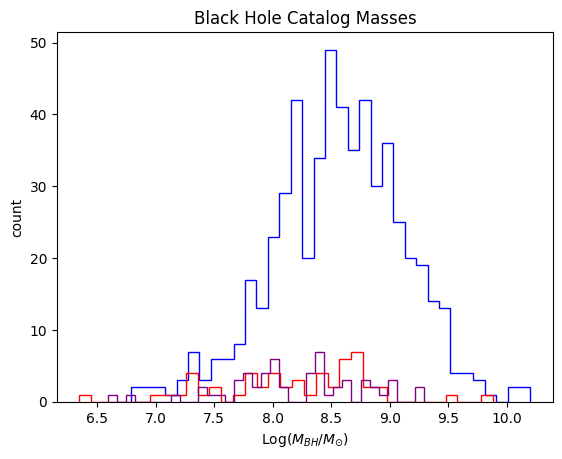

In [33]:
for i in range(len(Black_Hole_Catalog_All)):
    mass = Black_Hole_Catalog_All[i]['BH_Mass'].tolist()
    mass = [x for x in mass if x != None]

    num_bins = 35
    
    plt.hist(mass, num_bins, label =labels[i], color = colors[i], histtype='step')
    plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')
    plt.ylabel('count')
    plt.title('Black Hole Catalog Masses')
    #plt.legend(loc = 'upper right')

plt.savefig(outdir + 'BH_Catalog_mass.png')

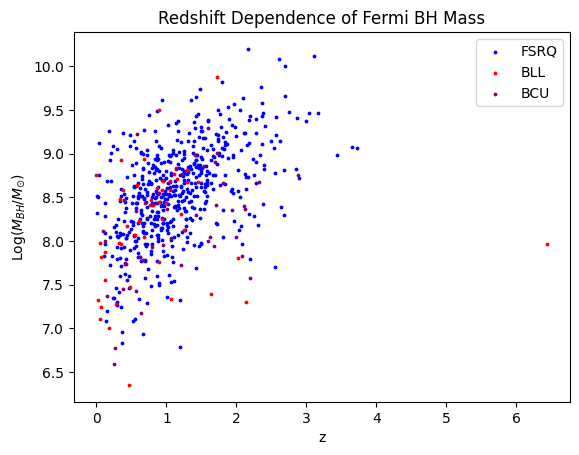

In [34]:
for i in range(len(Black_Hole_Catalog_All)):
    mass = Black_Hole_Catalog_All[i]['BH_Mass'].tolist()
    redshift = Black_Hole_Catalog_All[i]['Redshift'].tolist()
    m_z_zip = list(zip(mass,redshift))
    m_z_filtered = [x for x in m_z_zip if x[0] != None and x[1] != 'None']
    mass_filtered, redshift_filtered = list(zip(*m_z_filtered))
    redshift_filtered = [float(x) for x in redshift_filtered]

    plt.scatter(redshift_filtered, mass_filtered, color = colors[i], label = labels[i], s=3)
    plt.xlabel('z')
    plt.ylabel(r'Log($M_{BH}$/$M_{\odot}$)')
    plt.title('Redshift Dependence of Fermi BH Mass')
    plt.legend(loc='upper right')

plt.savefig(outdir + 'z_dependence_BHM.png')

# LAT Black Holes and Peak Matching

659
[0.644, 0.783, 1.732, 2.043, 1.52, 1.162, 2.69, 2.365, 0.2737, 1.062, 1.196, 0.882, 0.634, 1.08, 0.665, 0.128, 0.4329, 0.695, 0.591, 1.45, 0.21, 1.5512, 0.518, 1.422, 2.578000068664551, 2.4, 1.158, 0.296, 0.75, 0.743, 0.859, 1.686, 1.899, 1.106, 1.81, 0.88, 0.34667, 0.5978, 1.49043, 1.075, 0.473, 0.791, 1.57631, 1.72001, 0.227, 1.781, 0.545, 0.834, 1.804, 1.595, 2.045, 0.632, 1.426, 0.966, 1.032, 1.015, 1.161, 0.12132, 1.797, 0.92, 1.975, 1.2456, 1.369, 0.71901, 0.874, 0.874, 1.747, 0.44, 1.37462, 2.099, 1.1888, 0.77185, 0.389, 0.67, 1.49, 1.161, 0.72, 0.067, 1.63058, 1.02, 0.859, 0.83754, 0.3751, 1.16, 1.32, 2.287, 1.279, 1.35, 0.7604, 1.73949, 1.466, 0.895, 0.60653, 2.367, 1.715, 0.954, 0.7, 1.49, 1.0152, 0.511, 2.69, 1.679, 2.605, 1.019, 0.46657, 1.213, 0.94, 0.978, 2.68, 1.8, 2.243, 0.28287, 1.385, 1.427, 1.122, 0.539, 0.859, 1.391, 0.893, 0.8232, 1.351, 0.862, 1.48, 0.81639, 0.664, 0.636, 1.565, 2.066, 0.2070000022649765, 1.445, 1.258, 3.442, 0.852, 0.6830000281333923, 0.834, 

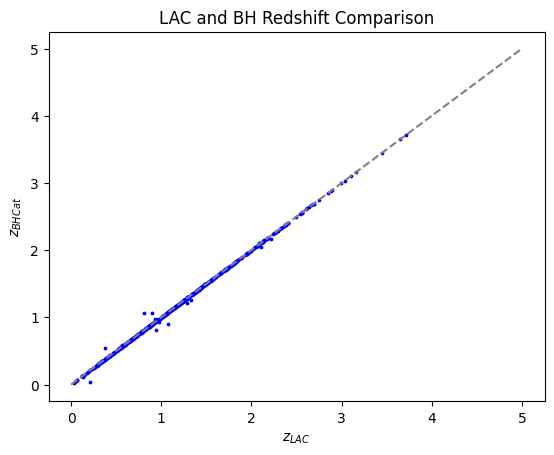

In [35]:
BH_cat_assoc = Black_Hole_Catalog['ASSOC_Name'].tolist()
BH_cat_assoc_ext = [x.ljust(28) for x in BH_cat_assoc]

LAC_assoc_mask = [x in BH_cat_assoc for x in Fermi_LAC_DR3['ASSOC1'].tolist()]
Fermi_LAC_masked = Fermi_LAC_DR3[LAC_assoc_mask]

LAT_assoc_mask = [x in BH_cat_assoc_ext for x in Fermi_LAT_DR4['ASSOC1'].tolist()]
Fermi_LAT_masked = Fermi_LAT_DR4[LAT_assoc_mask]

LAC_LAT_diff = difference_list_comp([r.strip(' ') for r in Fermi_LAT_masked['ASSOC1'].tolist()], Fermi_LAC_masked['ASSOC1'].tolist())

All_LAC_names = Fermi_LAC_masked['ASSOC1'].tolist()
Matched_names = [x for x in All_LAC_names if x != LAC_LAT_diff[0]]
print(len(Matched_names))
matched_redshifts = []
matched_IC_peak = []
matched_BH_mass = []
matched_IC_peak_err = []
matched_BH_mass_err = []
masked_names = []
matched_class = []

for i in Matched_names:

    LAT_mask = (LAT_IC_data['Assoc_Name'] == i)
    BH_mask = (Black_Hole_Catalog['ASSOC_Name'] == i)

    redshift_LAC = LAT_IC_data[LAT_mask]['Redshift'].tolist()[0]
    redshift_BH = Black_Hole_Catalog[BH_mask]['Redshift'].tolist()[0]
    gamma = LAT_IC_data[LAT_mask]['PL_Index'].tolist()[0]
    mass_BH = Black_Hole_Catalog[BH_mask]['BH_Mass'].tolist()[0]
    peak = LAT_IC_data[LAT_mask]['IC_E_peak'].tolist()[0]
    mass_BH_err = Black_Hole_Catalog[BH_mask]['BH_Mass_err'].tolist()[0]
    peak_err = LAT_IC_data[LAT_mask]['IC_E_peak_err'].tolist()[0]
    Class = LAT_IC_data[LAT_mask]['Class'].tolist()[0]

    if redshift_LAC != 'None' and redshift_BH != 'None':
        diff_redshift = abs(float(redshift_LAC) - float(redshift_BH))
        if diff_redshift <= 0.3:
            matched_redshifts.append(float(redshift_BH))
            matched_IC_peak.append(peak)
            matched_IC_peak_err.append(peak_err)
            matched_BH_mass_err.append(mass_BH_err)
            matched_BH_mass.append(mass_BH)
            masked_names.append(i)
            matched_class.append(Class)
            plt.scatter(float(redshift_LAC), float(redshift_BH), s=3, color='blue')
            plt.xlabel(r'$z_{LAC}$')
            plt.ylabel(r'$z_{BH Cat}$')
            plt.title('LAC and BH Redshift Comparison')
    elif redshift_LAC != 'None' and redshift_BH == 'None':
        matched_redshifts.append(float(redshift_LAC))
        matched_IC_peak.append(peak)
        matched_BH_mass.append(mass_BH)
        masked_names.append(i)
        matched_IC_peak_err.append(peak_err)
        matched_BH_mass_err.append(mass_BH_err)
        matched_class.append(Class)
    elif redshift_LAC == 'None' and redshift_BH != 'None':
        matched_redshifts.append(float(redshift_BH))
        matched_IC_peak.append(peak)
        matched_BH_mass.append(mass_BH)
        masked_names.append(i)
        matched_IC_peak_err.append(peak_err)
        matched_BH_mass_err.append(mass_BH_err)
        matched_class.append(Class)

x = np.linspace(0, 5, 100)
y = x
plt.plot(x, y, linestyle='--', color='grey', label='y = x')

print(matched_redshifts)
print(len(matched_redshifts))

Fermi_Joined_catalog = Table([masked_names, matched_class, matched_redshifts, matched_IC_peak, matched_IC_peak_err, matched_BH_mass, matched_BH_mass_err], names=['Name','Class', 'Redshift', 'IC_Peak_Energy', 'IC_Peak_Energy_Err', 'BH_Mass', 'BH_Mass_err'])
#Fermi_Joined_catalog.write(catalog_dir + 'Fermi_JOINED_catalog.fits', overwrite = True)

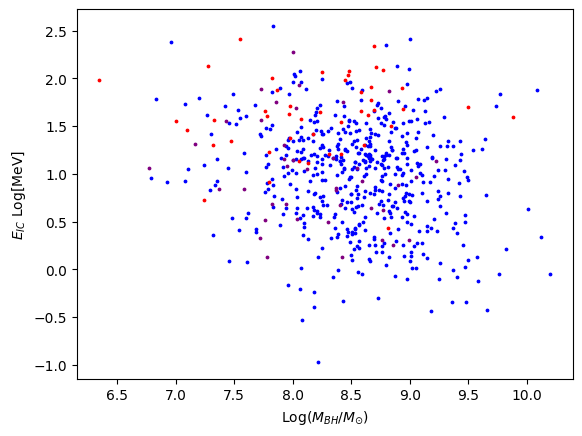

In [43]:
Fermi_Joined_catalog_FSRQ, Fermi_Joined_catalog_BLL, Fermi_Joined_catalog_BCU = mask_catalog_by_class(Fermi_Joined_catalog, 'Class')
Fermi_Joined_catalog_all = [Fermi_Joined_catalog_FSRQ, Fermi_Joined_catalog_BLL, Fermi_Joined_catalog_BCU]

for i in range(len(Fermi_Joined_catalog_all)):
    Mass = Fermi_Joined_catalog_all[i]['BH_Mass'].tolist()
    Energy = Fermi_Joined_catalog_all[i]['IC_Peak_Energy'].tolist()

    plt.scatter(Mass, Energy, s=3, color=colors[i],label=labels[i])
    plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')
    plt.ylabel(r'$E_{IC}$ Log[MeV]')

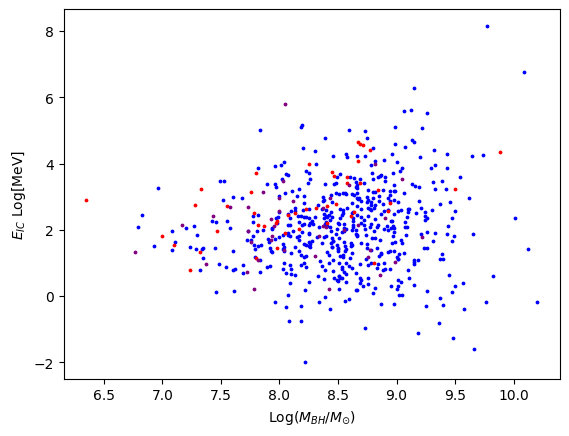

In [37]:
for i in range(len(Fermi_Joined_catalog_all)):
    Mass = Fermi_Joined_catalog_all[i]['BH_Mass'].tolist()
    Energy = Fermi_Joined_catalog_all[i]['IC_Peak_Energy'].tolist()
    redshift = Fermi_Joined_catalog_all[i]['Redshift'].tolist()

    Energy_corrected = []
    for x in range(len(Energy)):
        Energy_z_corr = (1 + float(redshift[x])) * Energy[x]
        Energy_corrected.append(Energy_z_corr)


    plt.scatter(Mass, Energy_corrected, s=3, color=colors[i],label=labels[i])
    plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')
    plt.ylabel(r'$E_{IC}$ Log[MeV]')

# Correlate

In [ ]:
slopes_0 = []
slopes_1 = []
intercepts_0 = []
intercepts_1 = []

slope_errors = []
intercept_errors = []

num_bins = np.arange(10,205,5)
for n in num_bins:
    redshift_bin_bounds = make_bin_bounds(matched_redshifts, n)

    binned_mass = [[] for n in range(len(redshift_bin_bounds) - 1)]
    binned_IC_peak = [[] for n in range(len(redshift_bin_bounds) - 1)]

    for i in range(len(masked_names)):

        for z in range(len(binned_mass)):
            if redshift_bin_bounds[z] <= matched_redshifts[i] < redshift_bin_bounds[z+1]:
                binned_mass[z].append(matched_BH_mass[i])
                binned_IC_peak[z].append(matched_IC_peak[i])

    averaged_BH_mass = []
    averaged_IC_peaks = []

    for i in range(len(binned_mass)):
        plt.scatter(mean(binned_mass[i]), mean(binned_IC_peak[i]), s = 3, color = 'blue')
        #plt.xlim(7.75,9.5)
        #plt.ylim(.6,1.1)
        plt.xlabel(r'Log($M_{BH}$/$M_{\odot}$)')
        plt.ylabel(r'$E_{IC}$ Log[MeV]')
        plt.title(f"{n} bins")
        averaged_BH_mass.append(mean(binned_mass[i]))
        averaged_IC_peaks.append(mean(binned_IC_peak[i]))

    averaged_BH_mass = np.array(averaged_BH_mass)
    averaged_IC_peaks = np.array(averaged_IC_peaks)
    
    popt,pcov = curve_fit(line,averaged_BH_mass,averaged_IC_peaks, p0=[8,1.1])
    plt.plot(averaged_BH_mass, line(averaged_BH_mass,*popt), color = 'grey', linestyle = '--')
    r2 = r2_score(averaged_IC_peaks, line(averaged_BH_mass,*popt))
    print(f"{n} Bins containing {(len(binned_mass[0]))} objects: r2 score = {r2}")
    #print(popt)
    slopes_0.append(popt[0])
    intercepts_0.append(popt[1])

    perr = np.sqrt(np.diag(pcov))
    slope_err = perr[0]
    intercept_err = perr[1]
    slope_errors.append(slope_err)
    intercept_errors.append(intercept_err)

    plt.savefig(outdir + f'/Correlation_plots/E_BH_correl_{n}_bins.png', bbox_inches='tight')
    #plt.show()
    plt.close()

    bin_centers = []
    ratio = []

    for i in range(len(binned_mass)):
        avg_mass_peak_E_ratio = (mean(binned_mass[i]) / mean(binned_IC_peak[i]))
        redshift_bin_center = ((redshift_bin_bounds[i] + redshift_bin_bounds[i+1]) / 2)
        plt.scatter(redshift_bin_center, avg_mass_peak_E_ratio, color = 'blue', s = 4)
        plt.xlabel(r'z')
        plt.ylabel(r'Log($M_{BH}$/$M_{\odot}$) / $E_{IC}$ Log[MeV]')
        plt.title(f"{n} bins")
        ratio.append(avg_mass_peak_E_ratio)
        bin_centers.append(redshift_bin_center)
    
    ratio = np.array(ratio)
    bin_centers = np.array(bin_centers)

    popt,pcov = curve_fit(line,bin_centers,ratio, p0=[8,1.1])
    plt.plot(bin_centers, line(bin_centers,*popt), color = 'grey', linestyle = '--')
    #print(popt)
    slopes_1.append(popt[0])
    intercepts_1.append(popt[1])

    plt.savefig(outdir + f'/Correlation_plots/z_correl_{n}_bins.png', bbox_inches='tight')
    #plt.show()
    plt.close()

10 Bins containing 61 objects: r2 score = 0.7085621400192749
15 Bins containing 41 objects: r2 score = 0.5942671087405221
20 Bins containing 31 objects: r2 score = 0.519859281481959
25 Bins containing 25 objects: r2 score = 0.3898582029093074
30 Bins containing 21 objects: r2 score = 0.3251784241882997
35 Bins containing 18 objects: r2 score = 0.3747046212763855
40 Bins containing 16 objects: r2 score = 0.3154754667185006
45 Bins containing 14 objects: r2 score = 0.3003209751862913
50 Bins containing 13 objects: r2 score = 0.22640835402106363
55 Bins containing 12 objects: r2 score = 0.2703578260176899
60 Bins containing 11 objects: r2 score = 0.1952160154375
65 Bins containing 9 objects: r2 score = 0.23773018963748827
70 Bins containing 9 objects: r2 score = 0.25072807192658697
75 Bins containing 9 objects: r2 score = 0.18662304495980242
80 Bins containing 8 objects: r2 score = 0.25260149979140345
85 Bins containing 8 objects: r2 score = 0.1856052076928023
90 Bins containing 7 objects

Text(0, 0.5, 'intercept')

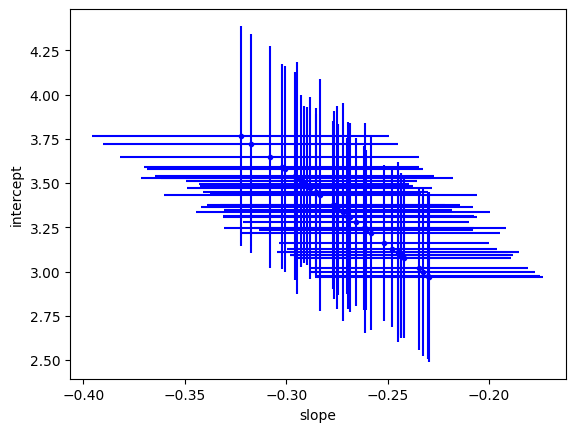

In [39]:
plt.errorbar(slopes_0, intercepts_0, xerr = slope_errors, yerr = intercept_errors, fmt = 'o',markersize=3, color = 'blue')
plt.xlabel('slope')
plt.ylabel('intercept')

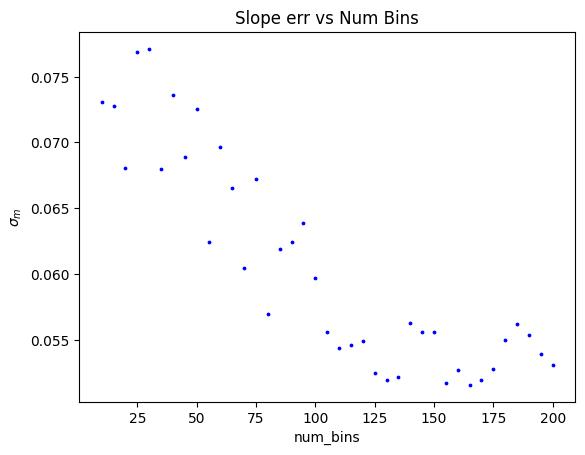

In [40]:
plt.scatter(num_bins, slope_errors, s =3, color='blue')
plt.ylabel(r'$\sigma_{m}$')
plt.xlabel(r'num_bins')
plt.title('Slope err vs Num Bins')
plt.savefig(outdir + 'Slope_err_behavior.png')

Text(0.5, 0, 'num_bins')

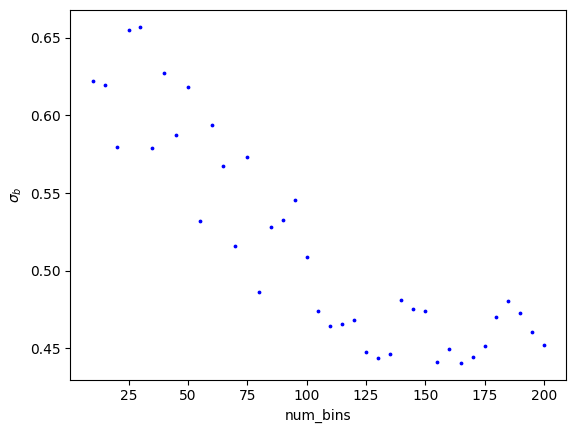

In [41]:
plt.scatter(num_bins, intercept_errors, s =3, color='blue')
plt.ylabel(r'$\sigma_{b}$')
plt.xlabel(r'num_bins')

Text(0, 0.5, 'intercept')

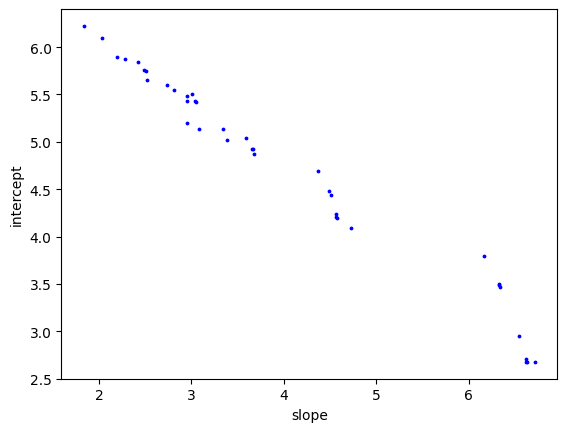

In [42]:
plt.scatter(slopes_1, intercepts_1, s = 3, color = 'blue')
plt.xlabel('slope')
plt.ylabel('intercept')